# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RodionOm/Search-ranking-ml/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

## 1. Ranked actions + reason codes

**The queue:** the top 50 pages by out-of-fold decline score, with **at most 5 pages per client** so one large client cannot fill the list. Each row has one action, "review & refresh", a confidence band and two reason codes.

**How the reason codes are made:** logistic regression is a weighted sum. For each page, contribution = model weight × how far this page's value is from the average (standardised). The two largest positive contributions become the reasons, written in plain words.

**Observed on this snapshot:** 46 of the 50 queued pages declined (0.92 vs base rate 0.54), covering 14 clients.

**Honest note on the reasons:** they are not very varied. "High recent visibility" appears in 46/50 rows, so the queue mostly says "big pages that grew recently tend to fall back". That is useful for prioritising, but it is a pattern, not a diagnosis. The reason tells the reviewer *where to look*, not *what is wrong* with the page.

In [1]:
import os
if not os.path.exists("data/raw/content_refresh_anonymized.csv"):
    !git clone -q https://github.com/flyrank-bih/flyrank-ml-internship-starter.git
    %cd flyrank-ml-internship-starter

import pandas as pd, numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
y = (df["trend_direction"] == "down").astype(int)
groups = df["client_id"]

X = pd.DataFrame(index=df.index)
for m in ["impressions", "clicks", "sessions"]:
    older = df[f"{m}_90d"] - df[f"{m}_last_30d"] - df[f"{m}_prev_30d"]
    X[f"log_{m}_older_30d"] = np.log1p(older)
    X[f"log_{m}_prev_30d"]  = np.log1p(df[f"{m}_prev_30d"])
X["early_momentum"] = X["log_impressions_prev_30d"] - X["log_impressions_older_30d"]
X["ctr_prev_30d"] = np.where(df["impressions_prev_30d"] > 0,
                             df["clicks_prev_30d"] / df["impressions_prev_30d"].replace(0, 1) * 100, 0)
X["content_age_days"] = df["content_age_days"]
X["has_word_count"] = df["word_count"].notna().astype(int)
X["word_count"] = df["word_count"].fillna(0)
X["has_keyword_data"] = df["search_volume"].notna().astype(int)
X["log_search_volume"] = np.log1p(df["search_volume"].fillna(0))
X["competition"] = df["competition"].fillna(0)
X["cpc"] = df["cpc"].fillna(0)
X = pd.concat([X, pd.get_dummies(df[["content_type", "main_intent"]].fillna("unknown"), dtype=int)], axis=1)

# honest scores: every page scored by a model that never saw its client (same as ML-08)
oof = np.zeros(len(df))
fold_of = np.zeros(len(df), dtype=int)
for i, (tr, te) in enumerate(GroupKFold(n_splits=5).split(X, y, groups)):
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(X.iloc[tr], y.iloc[tr])
    oof[te] = model.predict_proba(X.iloc[te])[:, 1]
    fold_of[te] = i
print("features:", X.shape, "| out-of-fold AUC:", round(roc_auc_score(y, oof), 3))

/content/flyrank-ml-internship-starter
features: (30000, 23) | out-of-fold AUC: 0.673


In [4]:
# 1) reason codes: which features pushed THIS page's score up?
final = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(X, y)
scaler, lr = final[0], final[-1]
contrib = pd.DataFrame(scaler.transform(X) * lr.coef_[0], columns=X.columns, index=X.index)

REASON_TEXT = {
    "log_impressions_prev_30d":  "high recent visibility (lots to lose)",
    "log_impressions_older_30d": "strong older traffic base",
    "early_momentum":            "recent spike (spikes often fall back)",
    "content_age_days":          "younger page, still settling",
    "log_clicks_prev_30d":       "few clicks for its impressions",
    "log_clicks_older_30d":      "few clicks historically",
    "ctr_prev_30d":              "low click-through rate",
}
def reasons(i, n=2):
    top = contrib.loc[i].sort_values(ascending=False).head(n)
    return "; ".join(REASON_TEXT.get(c, c) for c in top.index if top[c] > 0)

# 2) the queue: rank by score, max 5 pages per client, top 50
queue = pd.DataFrame({"content_id": df["content_id"], "client_id": groups,
                      "decline_score": oof, "declined_observed": y})
queue["confidence"] = pd.cut(queue["decline_score"], [0, 0.5, 0.7, 1.0], labels=["low", "medium", "high"])
queue = (queue.sort_values("decline_score", ascending=False, kind="stable")
              .groupby("client_id").head(5).head(50).reset_index())
queue["rank"] = range(1, len(queue) + 1)
queue["client"] = queue["client_id"].str[-4:]          # short anonymous code for display
queue["action"] = "review & refresh"
queue["reasons"] = [reasons(i) for i in queue["index"]]
queue["decline_score"] = queue["decline_score"].round(3)

print(queue[["rank", "client", "decline_score", "confidence", "reasons"]].head(10).to_string(index=False))
print("\nqueue precision (observed declines in top 50):", queue["declined_observed"].mean(),
      "| clients covered:", queue["client_id"].nunique(), "| base rate:", round(y.mean(), 3))
print("\nhow often each reason appears:")
print(queue["reasons"].str.split("; ").explode().value_counts().to_string())

 rank client  decline_score confidence                                                                      reasons
    1   27de          0.983       high             high recent visibility (lots to lose); strong older traffic base
    2   0f77          0.979       high             high recent visibility (lots to lose); strong older traffic base
    3   0f77          0.972       high             high recent visibility (lots to lose); strong older traffic base
    4   0f77          0.971       high             high recent visibility (lots to lose); strong older traffic base
    5   0f77          0.969       high             high recent visibility (lots to lose); strong older traffic base
    6   0f77          0.967       high             high recent visibility (lots to lose); strong older traffic base
    7   27de          0.967       high             high recent visibility (lots to lose); strong older traffic base
    8   27de          0.965       high high recent visibility (lots to l

## 2. Intended use and limits

## 2. Intended use and limits

**Who:** a content editor or SEO lead planning which pages to refresh this month.
**For what:** a short, ordered review list. It is decision support; it does not decide anything on its own.

**Confidence bands are honest in order, not in certainty** (out-of-fold):

| band | pages | observed decline rate |
|---|---|---|
| low (<0.5) | 9,584 | 0.35 |
| medium (0.5-0.7) | 10,432 | 0.59 |
| high (>0.7) | 9,984 | 0.69 |

"High" still means roughly 3 in 10 pages did **not** decline.

**Where it stops being valid:**
- **Mid-traffic pages:** AUC is only 0.57-0.59 there (vs 0.71 on low-traffic pages). Ranking inside this group is close to a coin flip.
- **Pages younger than 90 days:** the youngest page in the data is 90 days old, and the features need a full "older 30 days" window. The model has never seen a brand-new page.
- **New clients:** measured under GroupKFold, but per-client results varied (P@50 0.74-0.96 across folds).
- **One snapshot:** the label is one 30-day period. Seasonality and Google updates are not covered.
- **Not causal:** a high score means "similar pages declined", not "a refresh will stop the decline".

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# does "high confidence" really mean more declines? (checked on out-of-fold scores)
band = pd.cut(pd.Series(oof), [0, 0.5, 0.7, 1.0], labels=["low", "medium", "high"])
bands = pd.DataFrame({"declined": y, "band": band}).groupby("band", observed=True)["declined"] \
          .agg(pages="count", observed_decline_rate="mean").round(3)
print(bands, "\n")

# where is the model weak? AUC by traffic level
prev = df["impressions_prev_30d"]
d = pd.DataFrame({"y": y, "s": oof,
                  "traffic": pd.qcut(prev.rank(method="first"), 4, labels=["low", "mid-low", "mid-high", "high"])})
print(d.groupby("traffic", observed=True).apply(
    lambda g: pd.Series({"base_rate": g["y"].mean(), "auc": roc_auc_score(g["y"], g["s"])})).round(3), "\n")
print("youngest page in the data (days):", df["content_age_days"].min())

        pages  observed_decline_rate
band                                
low      9584                  0.346
medium  10432                  0.585
high     9984                  0.686 

          base_rate    auc
traffic                   
low           0.324  0.708
mid-low       0.613  0.566
mid-high      0.646  0.585
high          0.585  0.630 

youngest page in the data (days): 90


/tmp/ipykernel_1132/1414837325.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(d.groupby("traffic", observed=True).apply(


## 3. Human review + the no-go list
## 3. Human review + the no-go list

**Before acting on any queued page, a person checks:**
1. **Is the drop real?** Look at the page in Search Console: a seasonal topic, a tracking gap or a Google update can look like a decline.
2. **Was the spike a one-off?** 13 of the 50 pages are spike-driven (momentum > 1). A page that got one viral week may simply be returning to normal, and refreshing it will not help.
3. **Is there enough history?** 12 pages are 120 days old or younger, so their "older" window is short.
4. **Is the content actually outdated?** Facts, examples, prices, screenshots. If nothing is stale, there may be nothing to refresh.
5. **Does it matter to the business?** Traffic is not value. A high-traffic page with no business purpose can wait.

19 of the 50 rows carry at least one of these flags (`needs_extra_check = True`).

**No-go list: never automate**
- Auto-rewriting or auto-publishing content because of a score.
- Deleting, noindexing or redirecting pages based on the model.
- Ranking or judging writers or clients by their pages' scores.
- Using the score as a traffic forecast ("this page will lose X visits").
- Acting on pages under 90 days old, or on clients the model was not checked on, without a manual look.

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# human-review flags on the queue: reasons to look twice before acting
qd = df.loc[queue["index"]]
review_flags = pd.DataFrame({
    "short history (<=120 days)":     qd["content_age_days"].values <= 120,
    "spike-driven (momentum > 1)":    X.loc[queue["index"], "early_momentum"].values > 1,
    "no keyword data":                qd["search_volume"].isna().values,
    "tiny traffic (<50 prev impr.)":  qd["impressions_prev_30d"].values < 50,
})
queue["needs_extra_check"] = review_flags.any(axis=1).values
print(review_flags.sum().to_string())
print("queue rows with at least one flag:", int(queue["needs_extra_check"].sum()), "of", len(queue))

short history (<=120 days)       12
spike-driven (momentum > 1)      13
no keyword data                   1
tiny traffic (<50 prev impr.)     0
queue rows with at least one flag: 19 of 50


## 4. Monitoring / retrain triggers
## 4. Monitoring / retrain triggers

**Demo finding:** when each group of unseen clients is treated as a "new batch", every batch has PSI > 0.2 (score PSI 0.28-0.48), yet P@50 stays between 0.74 and 0.96. Clients simply look different from each other. So **input drift alone is a noisy alarm here**: it must be compared like-for-like (same clients, previous month), and the real trigger is measured precision once new labels arrive.

**Check monthly, after each new 30-day label window:**

| signal | how | trigger |
|---|---|---|
| **Queue precision** (main) | share of last month's top-50 that actually declined | below **0.80** (the old rule's level) for 2 months in a row → retrain or fall back to the rule |
| Base rate | share of all pages that declined | moves more than **10 points** → recheck the band thresholds |
| Score / feature drift | PSI vs the **same clients** last month | above **0.2** → investigate before trusting the queue |
| Reviewer feedback | share of queued pages a human rejects as "nothing to fix" | above **40%** → the reasons are not useful; revisit features |
| New client onboarded | n/a | always: manual review of their first queue |

**Retrain:** on a fixed schedule (e.g. quarterly), and at once after a known Google core update. Always re-validate with GroupKFold and the leakage trap test from ML-09 before switching models.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
def psi(reference, new, bins=10):
    """Population Stability Index: how much a distribution moved. <0.1 stable, 0.1-0.2 watch, >0.2 shifted."""
    edges = np.unique(np.quantile(reference, np.linspace(0, 1, bins + 1)))
    edges[0], edges[-1] = -np.inf, np.inf
    r = np.histogram(reference, edges)[0] / len(reference) + 1e-6
    n = np.histogram(new, edges)[0] / len(new) + 1e-6
    return float(np.sum((n - r) * np.log(n / r)))

# demo: treat each fold (a group of unseen clients) as "a new batch" vs the rest
rows = []
for f in range(5):
    m = fold_of == f
    top = np.argsort(-oof[m], kind="stable")[:50]
    rows.append([f, round(psi(oof[~m], oof[m]), 2),
                 round(psi(X["log_impressions_prev_30d"][~m], X["log_impressions_prev_30d"][m]), 2),
                 round(y[m].mean(), 2), round(y[m].values[top].mean(), 2)])
print(pd.DataFrame(rows, columns=["batch", "PSI_score", "PSI_prev_impr", "base_rate", "P@50"]).to_string(index=False))

## 5. Exports for the paper

## 5. Exports for the paper

Written to `work/outputs/`:
- `action_queue.csv`: the top-50 queue (rank, anonymised content id, short client code, score, confidence, action, reasons, review flag, observed outcome).
- `confidence_bands.csv`: band → pages → observed decline rate.
- `confidence_bands.png`: the bar chart of the same table, with the base rate line.

No client names or URLs: ids are the anonymised ones from the dataset, and clients are shown only as a 4-character code.

['action_queue.csv', 'confidence_bands.png', 'confidence_bands.csv']


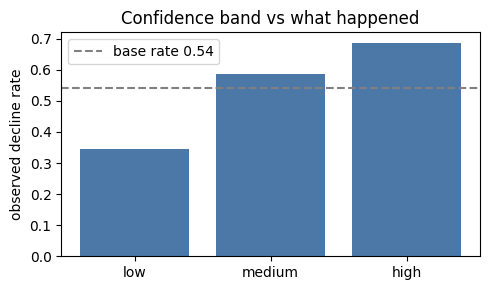

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
os.makedirs("work/outputs", exist_ok=True)
cols = ["rank", "content_id", "client", "decline_score", "confidence", "action", "reasons",
        "needs_extra_check", "declined_observed"]
queue[cols].to_csv("work/outputs/action_queue.csv", index=False)
bands.to_csv("work/outputs/confidence_bands.csv")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(bands.index.astype(str), bands["observed_decline_rate"], color="#4C78A8")
ax.axhline(y.mean(), color="gray", linestyle="--", label=f"base rate {y.mean():.2f}")
ax.set_ylabel("observed decline rate"); ax.set_title("Confidence band vs what happened")
ax.legend(); fig.tight_layout()
fig.savefig("work/outputs/confidence_bands.png", dpi=150)
print(os.listdir("work/outputs"))

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.